# Sales Prediction for Campaign Data

Section A: Data Understanding and Cleaning
---

In [43]:
# Read the messy training data CSV file and display the first fe_dfw rows of the DataFrame.
from pathlib import Path
import pandas as pd

csv_path = Path('/Data/messy_train_data.csv')
if not csv_path.exists():
    csv_path = Path('Data/messy_train_data.csv')

df = pd.read_csv(csv_path)

print("Sales Campaign Dataset Overview:")
print("=" * 80)
df.head()

Sales Campaign Dataset Overview:


,Followers,EngagementRate (%),AdSpend (GBP),ContentQuality,Sales (Units),ID,Timestamp,Notes
0,106572.0,2.573174871146172,2614.3781948587675,5.275680,6340,9254,2021-11-27,Pending
1,77583.0,0.9394984315675532,4975.962514379572,8.756268,5793,1561,2022-02-13,Review
2,92832.0,2.1761012652155296,4107.769534318886,6.454727,8104,1670,2023-09-25,Pending
3,53565.0,1.4783757541486553,4293.330464613049,4.312813,7293,6087,2023-02-15,Review
4,121079.0,3.3741976179329356,5343.549440897207,3.769047,14396,6669,2023-05-28,NaN


In [44]:
import numpy as np

print("Understand the scale of the dataset and the range of values in each column.")
print("=" * 80)
print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Total cells: {df.shape[0] * df.shape[1]:,}")

# High-level completeness and type view
column_profile = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "non_null": df.notna().sum(),
    "missing": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
    "unique_values": df.nunique(dropna=True),
})
print("\nColumn profile summary:")
display(column_profile.sort_values(["missing_pct", "unique_values"], ascending=[False, False]))


Understand the scale of the dataset and the range of values in each column.
Dataset shape: 8000 rows x 8 columns
Total cells: 64,000

Column profile summary:


,dtype,non_null,missing,missing_pct,unique_values
Notes,str,5348,2652,33.15,4
ContentQuality,float64,7840,160,2.00,7840
EngagementRate (%),str,7840,160,2.00,7800
Followers,float64,7840,160,2.00,7403
AdSpend (GBP),str,7841,159,1.99,7815
ID,int64,8000,0,0.00,8000
Sales (Units),int64,8000,0,0.00,5582
Timestamp,str,8000,0,0.00,1000


In [45]:
# "EngagementRate (%)" and "AdSpend (GBP)" are also numeric columns, but they are not in the numeric_cols list because they contain non-numeric characters (e.g., % and £). We need to clean these columns to convert them to numeric types.
df['EngagementRate (%)'] = df['EngagementRate (%)'].str.rstrip('%').astype(float)
df['AdSpend (GBP)'] = df['AdSpend (GBP)'].str.replace('£', '', regex=False).astype(float)

# Reprint the column profile summary after cleaning the numeric columns
column_profile = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "non_null": df.notna().sum(),
    "missing": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
    "unique_values": df.nunique(dropna=True),
})
print("\nColumn profile summary:")
display(column_profile.sort_values(["missing_pct", "unique_values"], ascending=[False, False]))



Column profile summary:


,dtype,non_null,missing,missing_pct,unique_values
Notes,str,5348,2652,33.15,4
ContentQuality,float64,7840,160,2.00,7840
EngagementRate (%),float64,7840,160,2.00,7800
Followers,float64,7840,160,2.00,7403
AdSpend (GBP),float64,7841,159,1.99,7814
ID,int64,8000,0,0.00,8000
Sales (Units),int64,8000,0,0.00,5582
Timestamp,str,8000,0,0.00,1000


In [46]:
print("Remove the rows with missing values in the source and target columns and reset the index.")
print("=" * 80)
df = df.dropna(subset=['ContentQuality', 'EngagementRate (%)', 'Followers', 'AdSpend (GBP)', 'Sales (Units)']).reset_index(drop=True)

# Remove the ID, Notes and Timestamp column as it is not needed for modeling
df = df.drop(columns=['ID', 'Notes', 'Timestamp'])

# High-level completeness and type view after removing rows with missing values in the source columns
column_profile_after = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "non_null": df.notna().sum(),
    "missing": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
    "unique_values": df.nunique(dropna=True),
})
print("\nColumn profile summary after removing rows with missing values in the source columns:")
display(column_profile_after.sort_values(["missing_pct", "unique_values"], ascending=[False, False]))


Remove the rows with missing values in the source and target columns and reset the index.

Column profile summary after removing rows with missing values in the source columns:


,dtype,non_null,missing,missing_pct,unique_values
ContentQuality,float64,7380,0,0.0,7380
AdSpend (GBP),float64,7380,0,0.0,7354
EngagementRate (%),float64,7380,0,0.0,7343
Followers,float64,7380,0,0.0,6997
Sales (Units),int64,7380,0,0.0,5264


In [47]:
print("Find the Range of values in each column and the most frequent value for categorical/text columns.")
print("=" * 80)
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = [c for c in df.columns if c not in numeric_cols]

if numeric_cols:
    print("\nNumeric column range summary:")
    numeric_summary = df[numeric_cols].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T
    numeric_summary = numeric_summary[["count", "mean", "std", "min", "1%", "5%", "25%", "50%", "75%", "95%", "99%", "max"]]
    display(numeric_summary)
else:
    print("\nNo numeric columns detected.")

if categorical_cols:
    print("\nCategorical/text column range summary:")
    cat_summary = pd.DataFrame({
        "unique_values": df[categorical_cols].nunique(dropna=True),
        "most_frequent": [df[c].mode(dropna=True).iloc[0] if not df[c].mode(dropna=True).empty else np.nan for c in categorical_cols],
        "most_frequent_count": [df[c].value_counts(dropna=True).iloc[0] if not df[c].value_counts(dropna=True).empty else 0 for c in categorical_cols],
    })
    display(cat_summary)
else:
    print("\nNo categorical/text columns detected.")

Find the Range of values in each column and the most frequent value for categorical/text columns.

Numeric column range summary:


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
Followers,7380.0,1.174418e+06,4.136149e+07,20.000000,88.000000,41446.550000,78277.500000,99275.000000,119779.000000,149281.050000,170343.230000,1.629447e+09
EngagementRate (%),7380.0,2.778012e+00,1.310289e+00,-4.648063,0.551445,0.721761,1.646868,2.794223,3.909384,4.789652,4.957164,4.999662e+00
AdSpend (GBP),7380.0,2.048846e+05,1.206409e+07,-7719.986555,1515.846111,2578.641071,3968.767358,4998.463830,5989.436237,7456.735811,8376.867399,9.322339e+08
ContentQuality,7380.0,5.504944e+00,2.608763e+00,1.000151,1.097549,1.453248,3.246930,5.487518,7.804982,9.565514,9.925436,9.999749e+00
Sales (Units),7380.0,1.054516e+04,2.795392e+03,590.000000,4072.950000,5969.950000,8655.000000,10501.000000,12450.250000,15177.000000,16906.730000,2.026300e+04



No categorical/text columns detected.


In [48]:
# Followers, AdSpend (GBP), EngagementRate (%) column have some skewed values showing some values in billions and in negatives, 

# Handle skewed values by converting to numeric, setting errors to NaN, and imputing missing values with median
for col in ["Followers", "AdSpend (GBP)", "EngagementRate (%)"]:
    df[col] = pd.to_numeric(df[col], errors="coerce") # Convert to numeric, setting errors to NaN
    df.loc[df[col] < 0, col] = np.nan  # Handle invalid negatives
    df[col] = df[col].fillna(df[col].median())  # Impute missing values with median
    if col != "EngagementRate (%)":  # Apply log transformation to reduce skewness 
        df[col] = np.log1p(df[col])

# Check the numeric ranges again after the imputation
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

print("\nNumeric column range summary after imputation:")
print("=" * 80)
numeric_summary = df[numeric_cols].describe(percentiles=[0.01, 0.5, 0.99]).T
numeric_summary = numeric_summary[["count", "mean", "std", "min", "1%", "50%", "99%", "max"]]
display(numeric_summary)

print("Data preprocessing completed. The dataset is now ready for model training.")
print("=" * 80)


Numeric column range summary after imputation:


,count,mean,std,min,1%,50%,99%,max
Followers,7380.0,11.299090,1.158334,3.044522,4.488636,11.505659,12.045576,21.211507
EngagementRate (%),7380.0,2.780412,1.304341,0.501136,0.554067,2.794517,4.957164,4.999662
AdSpend (GBP),7380.0,8.468498,0.406437,6.908755,7.336105,8.517181,9.033348,20.653094
ContentQuality,7380.0,5.504944,2.608763,1.000151,1.097549,5.487518,9.925436,9.999749
Sales (Units),7380.0,10545.163415,2795.392069,590.000000,4072.950000,10501.000000,16906.730000,20263.000000


Data preprocessing completed. The dataset is now ready for model training.


Section B: Exploratory Data Analysis (EDA)
---

Explore the data to understand how different campaign factors relate to sales.

In [49]:
# Cell 1: Setup for EDA
import matplotlib.pyplot as plt

# Use a copy so you don't accidentally overwrite training data
df_new = df.copy()

target = "Sales (Units)"
num_cols = ["Followers", "AdSpend (GBP)", "EngagementRate (%)", "ContentQuality"]
num_cols

['Followers', 'AdSpend (GBP)', 'EngagementRate (%)', 'ContentQuality']

In [50]:
# Cell 2: Correlation with Sales (linear + rank-based)
pearson_corr = df_new[num_cols + [target]].corr(method="pearson")[target].drop(target).sort_values(ascending=False)
spearman_corr = df_new[num_cols + [target]].corr(method="spearman")[target].drop(target).sort_values(ascending=False)

corr_summary = pd.DataFrame({
    "pearson_with_sales": pearson_corr,
    "spearman_with_sales": spearman_corr
}).sort_values("spearman_with_sales", ascending=False)

display(corr_summary)

,pearson_with_sales,spearman_with_sales
Followers,0.182384,0.506706
AdSpend (GBP),0.341245,0.396379
ContentQuality,0.169561,0.168212
EngagementRate (%),0.073470,0.072381


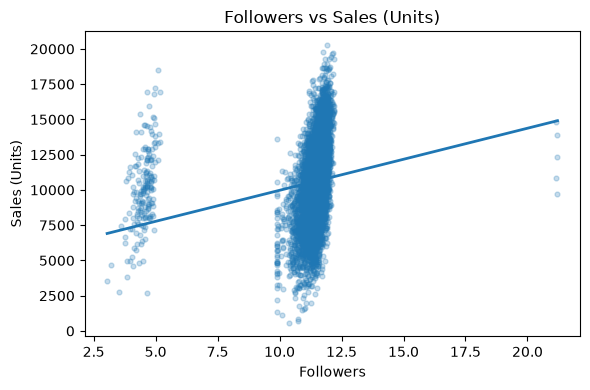

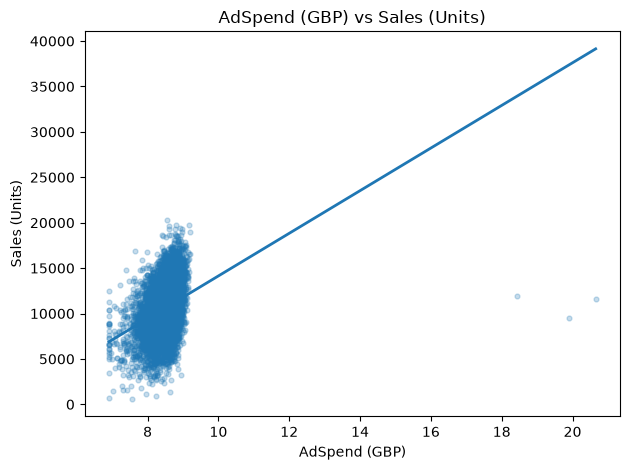

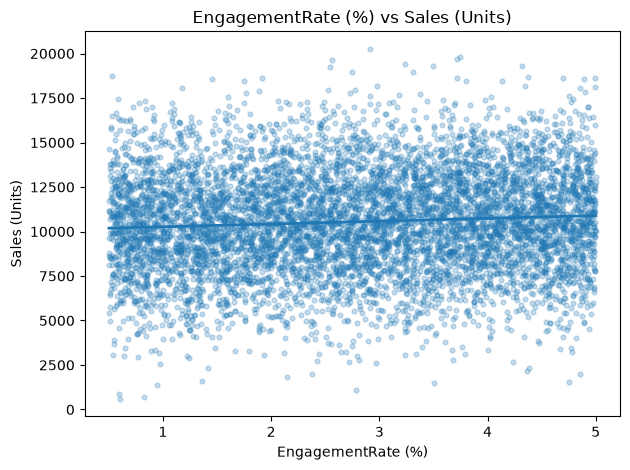

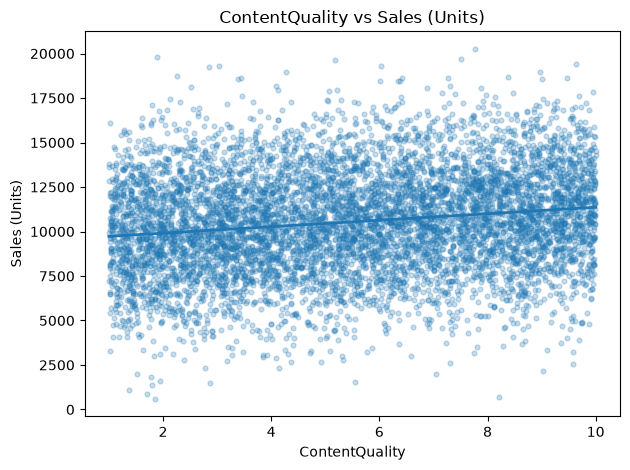

In [51]:
plt.figure(figsize=(6, 4))
    
# Cell 3: Scatter plots with simple trend line for each numeric feature
for col in num_cols:
    x = df_new[col].values
    y = df_new[target].values
    
    plt.scatter(x, y, alpha=0.25, s=12)    
    # Fit linear trend line
    m, b = np.polyfit(x, y, 1)
    x_line = np.linspace(np.nanmin(x), np.nanmax(x), 100)
    plt.plot(x_line, m * x_line + b, linewidth=2)
    
    plt.title(f"{col} vs {target}")
    plt.xlabel(col)
    plt.ylabel(target)
    plt.tight_layout()
    plt.show()

**Charts interpretation -** 

1. Followers vs Sales:
Trend line slopes upward, but the scatter is clustered with visible pockets and a few extreme points. This supports a non-linear “scale effect” where larger followers tend to sell more, with diminishing/irregular gains.

2. AdSpend vs Sales:
Clear upward trend in dense central region, but a few high-spend outliers pull the fitted line upward. Core data supports positive return on spend, though not uniformly at extreme spend levels.

3. EngagementRate vs Sales:
Almost flat cloud with slight upward tilt. High dispersion at all engagement levels suggests engagement does not independently explain sales variance well.

4. ContentQuality vs Sales:
Slight upward slope with broad spread. Content quality likely helps, but acts as a supporting driver rather than a primary one.

**Business interpretation -**
1. Scale and budget matter most:
Influencer followers and campaign spend are the strongest levers for expected sales volume.

2. Efficiency is not guaranteed at extremes:
Very high spend or very large influencer values may not proportionally increase sales.

3. Quality and engagement are complementary:
They likely improve outcomes in combination with followers/spend, not as standalone drivers.

Section C: Feature Engineering
---

In [52]:
# Section C: Feature Engineering
print("Apply feature engineering to improve model predictive power.")
print("=" * 80)

from sklearn.preprocessing import StandardScaler

target = "Sales (Units)"
fe_df = df.copy()

# Keep a safe, model-ready numeric subset
base_features = ["Followers", "EngagementRate (%)", "AdSpend (GBP)", "ContentQuality"]
fe_df = fe_df.dropna(subset=base_features + [target]).copy()

# 1) Interaction features (marketing intuition: impact depends on combinations)
fe_df["followers_x_engagement"] = fe_df["Followers"] * fe_df["EngagementRate (%)"]
fe_df["followers_x_adspend"] = fe_df["Followers"] * fe_df["AdSpend (GBP)"]
fe_df["followers_x_quality"] = fe_df["Followers"] * fe_df["ContentQuality"]

# Clip extreme engineered tails to reduce instability
engineered_cols = ["followers_x_engagement", "followers_x_adspend", "followers_x_quality"]

for c in engineered_cols:
    lo, hi = fe_df[c].quantile([0.01, 0.99])
    fe_df[c] = fe_df[c].clip(lo, hi)

# Prepare final feature matrix
feature_cols = base_features + engineered_cols
X = fe_df[feature_cols].copy()
y = fe_df[target].copy()

# Scale features for scale-sensitive models
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=feature_cols, index=X.index)

print(f"Feature matrix shape: {X.shape}")
print(f"Scaled feature matrix shape: {X_scaled.shape}")
print("\nEngineered feature columns:")
display(pd.Series(feature_cols, name="feature_name"))

# Quick diagnostic: correlation of engineered features with target
fe_corr = fe_df[feature_cols + [target]].corr(method="spearman")[target].drop(target).sort_values(ascending=False)
print("\nSpearman correlation of features with Sales (Units):")
display(fe_corr.to_frame("spearman_with_sales"))

print("\nFeature engineering complete. Variables ready for modeling:")
print("- X (unscaled features)")
print("- X_scaled (standardized features)")
print("- y (target)")

Apply feature engineering to improve model predictive power.
Feature matrix shape: (7380, 7)
Scaled feature matrix shape: (7380, 7)

Engineered feature columns:


0                 Followers
1        EngagementRate (%)
2             AdSpend (GBP)
3            ContentQuality
4    followers_x_engagement
5       followers_x_adspend
6       followers_x_quality
Name: feature_name, dtype: str


Spearman correlation of features with Sales (Units):


,spearman_with_sales
followers_x_adspend,0.605097
Followers,0.506706
AdSpend (GBP),0.396379
followers_x_quality,0.201182
ContentQuality,0.168212
followers_x_engagement,0.107924
EngagementRate (%),0.072381



Feature engineering complete. Variables ready for modeling:
- X (unscaled features)
- X_scaled (standardized features)
- y (target)


# Section D: Model Building
Train a regression model that can predict sales from campaign attributes.

In [53]:
print("Model Building: baseline and robust regression with validation")
print("=" * 80)

from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Build a fresh modeling frame from cleaned df to avoid accidental reuse artifacts
model_df = fe_df.copy()

X = model_df[feature_cols]
y = model_df[target]

# Holdout split for final validation
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Every model starts with median imputation, so a fitted pipeline can still score
# real-world rows that arrive with missing values - not just the cleaned frame.
# The imputer learns its medians inside each CV fold, so no test data leaks in.
def build_pipeline(estimator, scale=True):
    steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale:
        steps.append(("scaler", StandardScaler()))
    steps.append(("model", estimator))
    return Pipeline(steps)

# Models: baseline first, then stronger/robust options
models = {
    "Baseline_Mean": build_pipeline(DummyRegressor(strategy="mean"), scale=False),
    "LinearRegression": build_pipeline(LinearRegression()),
    "Ridge": build_pipeline(Ridge(alpha=1.0, random_state=42)),
    "RandomForest": build_pipeline(
        RandomForestRegressor(
            n_estimators=400, max_depth=None, min_samples_leaf=3, random_state=42, n_jobs=-1),
        scale=False),
    "LightGBM": build_pipeline(
        LGBMRegressor(
            n_estimators=400, max_depth=-1, learning_rate=0.05, random_state=42, n_jobs=-1, verbose=-1),
        scale=False),
    "XGBoost": build_pipeline(
        XGBRegressor(
            n_estimators=400, learning_rate=0.05, max_depth=5,
            subsample=0.8, colsample_bytree=0.8,
            reg_lambda=1.0, min_child_weight=5,
            random_state=42, n_jobs=-1, tree_method="hist"),
        scale=False)

}

# Cross-validation on training split to reduce overfitting risk
cv = KFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2"
}

cv_rows = []
for name, model in models.items():
    cv_out = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring,
                            return_train_score=True, n_jobs=-1)
    cv_rows.append({
        "model": name,
        "cv_rmse_mean": -cv_out["test_rmse"].mean(),
        "cv_rmse_std": cv_out["test_rmse"].std(),
        "cv_mae_mean": -cv_out["test_mae"].mean(),
        "train_r2_mean": cv_out["train_r2"].mean(),
        "cv_r2_mean": cv_out["test_r2"].mean(),
        "r2_gap": cv_out["train_r2"].mean() - cv_out["test_r2"].mean()
    })

cv_results = pd.DataFrame(cv_rows).sort_values("cv_rmse_mean")
print("\n5-Fold CV Performance (train split only):")
display(cv_results)

# Champion is chosen on cross-validation alone, so the holdout stays genuinely unseen
best_model = cv_results.iloc[0]["model"]
print(f"\nChampion selected on CV only: {best_model}")
print("                           ====================")


Model Building: baseline and robust regression with validation

5-Fold CV Performance (train split only):


,model,cv_rmse_mean,cv_rmse_std,cv_mae_mean,train_r2_mean,cv_r2_mean,r2_gap
5,XGBoost,2057.912280,54.949085,1649.088281,0.718038,0.457015,0.261023
3,RandomForest,2060.438473,63.804831,1648.850353,0.830747,0.455688,0.375058
4,LightGBM,2092.446114,56.855681,1677.179357,0.760348,0.438649,0.321699
2,Ridge,2539.608664,81.800680,1986.722776,0.212930,0.171694,0.041237
1,LinearRegression,2540.461533,82.743141,1986.831023,0.212935,0.171086,0.041848
0,Baseline_Mean,2794.505155,45.461656,2234.407704,0.000000,-0.000769,0.000769



Champion selected on CV only: XGBoost


In [54]:

# Fit on full train split and evaluate on untouched holdout
holdout_rows = []
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    holdout_rows.append({
        "model": name,
        "holdout_rmse": mean_squared_error(y_test, pred) ** 0.5,
        "holdout_mae": mean_absolute_error(y_test, pred),
        "holdout_r2": r2_score(y_test, pred)
    })

holdout_results = pd.DataFrame(holdout_rows).sort_values("holdout_rmse")
print("\nHoldout Performance (20% unseen data, reported after the model was chosen):")
display(holdout_results)

champion = holdout_results.loc[holdout_results["model"] == best_model].iloc[0]
print(f"\nUnbiased holdout estimate for {best_model}: "
      f"RMSE={champion['holdout_rmse']:.1f}, "
      f"MAE={champion['holdout_mae']:.1f}, "
      f"R2={champion['holdout_r2']:.3f}")

# Smoke test: the champion must survive rows with missing values, not just clean ones
nan_probe = X_test.head(5).copy()
nan_probe.iloc[:, 0] = np.nan
print("\nMissing-value smoke test (Followers blanked on 5 holdout rows):")
print(np.round(models[best_model].predict(nan_probe), 1))

print(f"\nUsing '{best_model}' as the current champion model for the next tuning step.")


Holdout Performance (20% unseen data, reported after the model was chosen):


,model,holdout_rmse,holdout_mae,holdout_r2
5,XGBoost,2034.755514,1621.590820,0.470627
3,RandomForest,2043.036643,1627.348455,0.466309
4,LightGBM,2057.893865,1645.421241,0.458519
2,Ridge,2425.804426,1918.025251,0.247600
1,LinearRegression,2425.867824,1917.939338,0.247560
0,Baseline_Mean,2798.437804,2231.463673,-0.001310



Unbiased holdout estimate for XGBoost: RMSE=2034.8, MAE=1621.6, R2=0.471

Missing-value smoke test (Followers blanked on 5 holdout rows):
[11232.5 10192.3 10333.3  8608.1  9859.1]

Using 'XGBoost' as the current champion model for the next tuning step.


# Section E: Model Evaluation and Tuning

Evaluate how well your model performs and improve its reliability.
Hints
 - Use error-based metrics to understand how far predictions are from actual sales values.
 - Compare model performance across different configurations to identify meaningful improvements.
 - Pay attention to consistency of results across validation folds rather than a single score.

In [55]:
print("Model Evaluation: regression error metrics on the untouched holdout")
print("=" * 80)

from sklearn.metrics import mean_absolute_percentage_error

def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    resid = y_test.to_numpy() - y_pred
    ape = np.abs(resid) / np.abs(y_test.to_numpy())
    
    metrics = {
        "RMSE": np.sqrt(np.mean(resid ** 2)),
        "MAE": np.mean(np.abs(resid)),
        "MAPE": mean_absolute_percentage_error(y_test, y_pred) * 100,
        "R2": r2_score(y_test, y_pred),
        "Bias": resid.mean()
    }
    
    return ape, resid, metrics

ape, resid, model_metrics = evaluate_model(models[best_model], X_test, y_test)
display(pd.DataFrame(model_metrics, index=[best_model]).T.rename(columns={0: "value"}))

# Same metrics for the baseline, so the champion's error has something to beat
baseline_pred = models["Baseline_Mean"].predict(X_test)
baseline_rmse = mean_squared_error(y_test, baseline_pred) ** 0.5
champion_rmse = np.sqrt(np.mean(resid ** 2))
print(f"\nBaseline RMSE: {baseline_rmse:,.1f} units")
print(f"Improvement over baseline: {(1 - champion_rmse / baseline_rmse) * 100:.1f}% lower RMSE")
print(f"Predictions within 20% of actual: {np.mean(ape <= 0.20) * 100:.1f}% of campaigns")

Model Evaluation: regression error metrics on the untouched holdout


,XGBoost
RMSE,2034.755530
MAE,1621.590900
MAPE,18.177034
R2,0.470627
Bias,-20.058909



Baseline RMSE: 2,798.4 units
Improvement over baseline: 27.3% lower RMSE
Predictions within 20% of actual: 68.8% of campaigns


In [56]:
print("\nFine tuning the champion model with hyperparameter search and cross-validation")
print("=" * 80)
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor

model = XGBRegressor(
    objective="reg:squarederror",
    random_state=42
)

param_grid = {
    "n_estimators": [200, 400, 600, 800, 1000],
    "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "max_depth": [3, 4, 5, 6, 8, 10],
    "min_child_weight": [1, 3, 5, 10],
    "subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "gamma": [0, 0.1, 0.3, 0.5, 1],
    "reg_alpha": [0, 0.01, 0.1, 1],
    "reg_lambda": [1, 2, 5, 10]
}

random_search = RandomizedSearchCV(
    model,
    param_distributions=param_grid,
    n_iter=50,
    scoring="neg_mean_squared_error",
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)
print("\n Best hyperparameters found:")
display(random_search.best_params_)



 Fine tuning the champion model with hyperparameter search and cross-validation
Fitting 5 folds for each of 50 candidates, totalling 250 fits

 Best hyperparameters found:


{'subsample': 0.7,
 'reg_lambda': 10,
 'reg_alpha': 0.01,
 'n_estimators': 1000,
 'min_child_weight': 3,
 'max_depth': 3,
 'learning_rate': 0.01,
 'gamma': 1,
 'colsample_bytree': 0.9}

In [57]:
print("\nBest model evaluation metrics on the holdout set:")
print("=" * 80) 
ape_tuned, resid_tuned, model_tuned = evaluate_model(random_search.best_estimator_, X_test, y_test)

print("\nTuned model evaluation metrics:")
display(pd.DataFrame(model_tuned, index=["Tuned " + best_model]).T.rename(columns={0: "value"}))

print("\nComparison of baseline, and tuned model performance:")
comparison_df = pd.DataFrame({
    "Baseline " + best_model: model_metrics,
    "Tuned " + best_model: model_tuned
}).T.rename(columns={0: "value"})
display(comparison_df)


Best model evaluation metrics on the holdout set:

Tuned model evaluation metrics:


,Tuned XGBoost
RMSE,2003.233134
MAE,1588.284182
MAPE,17.940639
R2,0.486902
Bias,-31.119277



Comparison of baseline, and tuned model performance:


,RMSE,MAE,MAPE,R2,Bias
Baseline XGBoost,2034.755530,1621.590900,18.177034,0.470627,-20.058909
Tuned XGBoost,2003.233134,1588.284182,17.940639,0.486902,-31.119277


# Section F: Business Insights and Pipeline Design
Goal
-
Translate model results into actionable insights and design a solution that can be reused.


Feature importance from the tuned champion model:


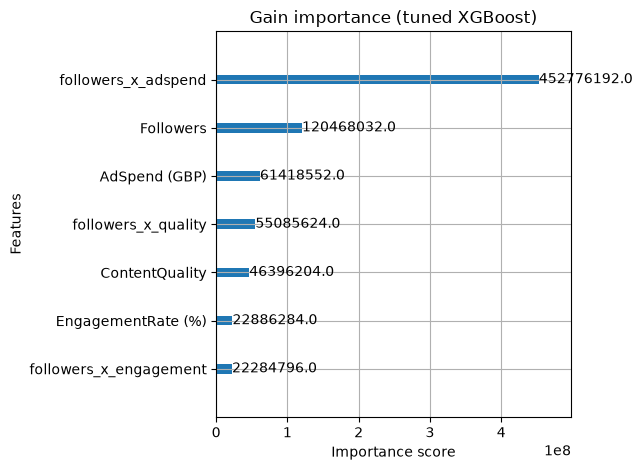


Top 3 features by gain importance (percentage of total gain):


followers_x_adspend    71.339996
Followers              18.980000
AdSpend (GBP)           9.680000
dtype: float32


Top 3 vs all other features collectively account for 81.23% vs 18.77% of total gain importance.

Feature importance analysis complete. The top features have been identified and their contribution to the model's predictive power has been quantified.


In [68]:
print("\nFeature importance from the tuned champion model:")
print("=" * 80)
import matplotlib.pyplot as plt
from xgboost import plot_importance
from sklearn.inspection import permutation_importance

tuned_estimator = random_search.best_estimator_

# 1) Gain: average loss improvement over the splits each feature was used in.
plot_importance(tuned_estimator, importance_type="gain")
plt.title("Gain importance (tuned XGBoost)")
plt.tight_layout()
plt.show()

# 2) Find the top 3 features by gain importance and their percentage of total gain
top_3 = pd.Series(tuned_estimator.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(3)

top_3_perc = (top_3 / top_3.sum() * 100).round(2)
print("\nTop 3 features by gain importance (percentage of total gain):")
display(top_3_perc)

# 3) Calculate the percentage of total gain importance for the top 3 features vs all other features collectively
top_3_perc = (top_3 / tuned_estimator.feature_importances_.sum() * 100).round(2)
rest_all_perc = (1 - top_3.sum() / tuned_estimator.feature_importances_.sum()) * 100
print(f"\nTop 3 vs all other features collectively account for {top_3_perc.sum():.2f}% vs {rest_all_perc:.2f}% of total gain importance.")

print("\nFeature importance analysis complete. The top features have been identified and their contribution to the model's predictive power has been quantified.")
